In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping,  ReduceLROnPlateau
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import tensorflow as transforms
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os







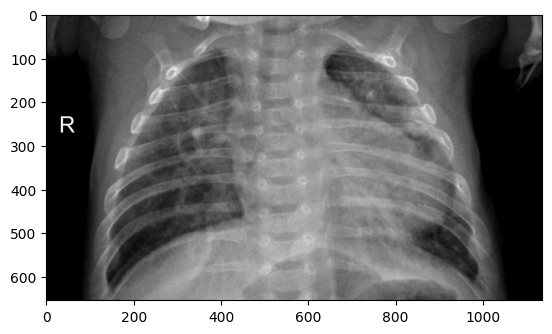

In [4]:
img= image.load_img("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/test/PNEUMONIA/person1_virus_13.jpeg")
plt.imshow(img)

In [5]:
tamaño=cv2.imread("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/train/PNEUMONIA/person2_bacteria_4.jpeg")
print(tamaño)

[[[28 28 28]
  [30 30 30]
  [31 31 31]
  ...
  [41 41 41]
  [41 41 41]
  [41 41 41]]

 [[29 29 29]
  [30 30 30]
  [31 31 31]
  ...
  [41 41 41]
  [41 41 41]
  [41 41 41]]

 [[29 29 29]
  [30 30 30]
  [31 31 31]
  ...
  [41 41 41]
  [41 41 41]
  [41 41 41]]

 ...

 [[29 29 29]
  [31 31 31]
  [35 35 35]
  ...
  [23 23 23]
  [23 23 23]
  [23 23 23]]

 [[30 30 30]
  [30 30 30]
  [32 32 32]
  ...
  [23 23 23]
  [23 23 23]
  [23 23 23]]

 [[30 30 30]
  [29 29 29]
  [29 29 29]
  ...
  [23 23 23]
  [23 23 23]
  [23 23 23]]]


In [9]:
tamaño=cv2.imread("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/train/PNEUMONIA/person2_bacteria_4.jpeg").shape
print(tamaño)

(1160, 1328, 3)


# Modelo1


In [ ]:
train = ImageDataGenerator (rescale= 1/255,                       
                            rotation_range=20,
                            horizontal_flip=True,
                            width_shift_range=0.1,
                            height_shift_range=0.1
                            )
val= ImageDataGenerator (rescale= 1/255)
test= ImageDataGenerator (rescale= 1/255)

In [ ]:
Train_dataset = train.flow_from_directory("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/train/", 
                                          target_size= (200,200),
                                          batch_size = 32,
                                          class_mode = 'binary')
Val_dataset = val.flow_from_directory("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/val/", 
                                          target_size= (200,200),
                                          batch_size = 16,
                                          class_mode = 'binary',
                                          shuffle=False)
Test_dataset = test.flow_from_directory("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/test/", 
                                          target_size= (200,200),
                                          batch_size = 32,
                                          class_mode = 'binary',
                                          shuffle=False)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [27]:
Train_dataset.class_indices


{'NORMAL': 0, 'PNEUMONIA': 1}

In [28]:

model = Sequential()


model.add(Conv2D(32, (3, 3), activation='relu', padding='same',input_shape=(200, 200, 3)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

c:\Users\Usuaria\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
CNn= model
CNn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall'])

In [30]:
history = CNn.fit(
    Train_dataset,                    
    epochs=20,                        
    validation_data=Val_dataset,                      
    verbose=1,                                           
)

c:\Users\Usuaria\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.7699 - loss: 0.4798 - precision: 0.7803 - recall: 0.9608 - val_accuracy: 0.6875 - val_loss: 0.6591 - val_precision: 0.6364 - val_recall: 0.8750
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.8890 - loss: 0.2697 - precision: 0.9219 - recall: 0.9293 - val_accuracy: 0.6875 - val_loss: 0.5093 - val_precision: 0.6364 - val_recall: 0.8750
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9107 - loss: 0.2208 - precision: 0.9369 - recall: 0.9432 - val_accuracy: 0.8125 - val_loss: 0.5025 - val_precision: 0.8571 - val_recall: 0.7500
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.9224 - loss: 0.1946 - precision: 0.9460 - recall: 0.9497 - val_accuracy: 0.6875 - val_loss: 0.5150 - val_precision: 0.6364 - val_recall: 0.8750
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9248 - loss: 0.1833 - precision: 0.9487 - recall: 0.9502 - val_accuracy: 0.8750 - val_los

- accuracy: 0.9605 
- loss: 0.1094 
- precision: 0.9734 
- recall: 0.9734 
- val_accuracy: 0.8750 
- val_loss: 0.2948 
- val_precision: 0.8000 
- val_recall: 1.0000

In [ ]:
CNn.save('CNn1.h5')

In [48]:

test_loss, test_accuracy, test_precision, test_recall = CNn.evaluate(Test_dataset, verbose=1)

print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
print(f"Precision: {test_precision:.4f} ({test_precision:.1%})")
print(f"Recall: {test_recall:.4f} ({test_recall:.1%})")


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - accuracy: 0.7772 - loss: 0.5471 - precision: 0.7485 - recall: 0.9692
Loss: 0.5471
Accuracy: 0.7772 (77.7%)
Precision: 0.7485 (74.9%)
Recall: 0.9692 (96.9%)


Loss: 0.5471

Accuracy: 0.7772 (77.7%)

Precision: 0.7485 (74.9%)

Recall: 0.9692 (96.9%)

In [58]:
y_pred_prob = CNn.predict(Test_dataset)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = Test_dataset.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 666ms/step


In [59]:
f1 = f1_score(y_true, y_pred)
print(f"\nF1-SCORE: {f1:.4f} ({f1:.1%})")


F1-SCORE: 0.8447 (84.5%)


[[107 127]
 [ 12 378]]


<Axes: >

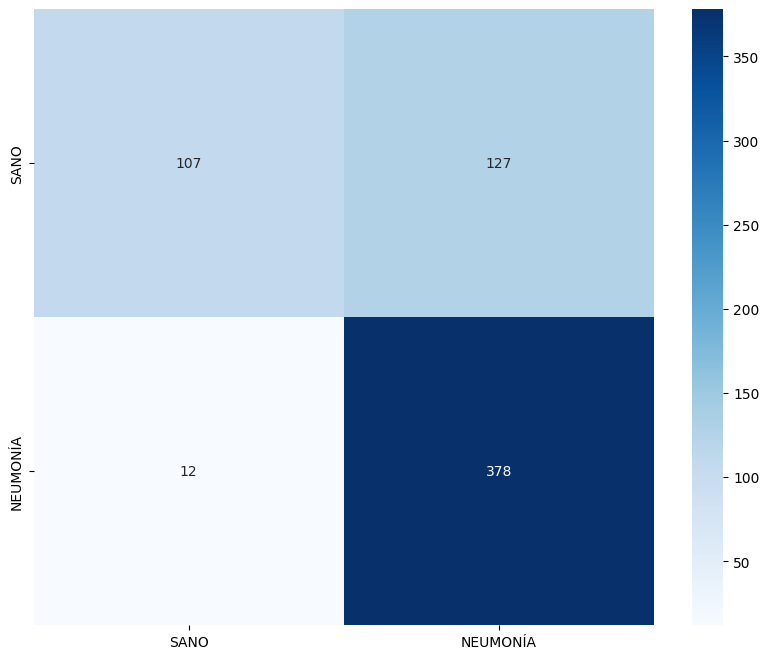

In [67]:
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['SANO', 'NEUMONÍA'], 
            yticklabels=['SANO', 'NEUMONÍA'])

-------------------------------------------------------------

# Modelo 2 

con cambios en el ImageDataGenerator,misma arquitectura que modelo 1, mas epocas y se agrego early stop

In [10]:

train2 = ImageDataGenerator(
    rescale=1/255,
    rotation_range=20,           
    horizontal_flip=True,        
    width_shift_range=0.1,       
    height_shift_range=0.1,      
    zoom_range=0.1,              
    brightness_range=[0.95, 1.05] 
)

Train_dataset2= train2.flow_from_directory("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/train/", 
                                          target_size= (200,200),
                                          batch_size = 32,
                                          class_mode = 'binary')

Found 5216 images belonging to 2 classes.


In [11]:
model2 = Sequential()


model2.add(Conv2D(32, (3, 3), activation='relu', padding='same',input_shape=(200, 200, 3)))
model2.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model2.add(MaxPooling2D((2, 2)))

model2.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(MaxPooling2D((2, 2)))

model2.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model2.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model2.add(MaxPooling2D((2, 2)))

model2.add(Flatten())
model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(1, activation='sigmoid'))

c:\Users\Usuaria\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:

CNn2=model2

CNn2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

early_stop = EarlyStopping(
    monitor='val_loss',           
    patience=5,                   
    restore_best_weights=True,    
    verbose=1
)


In [52]:
history2 = CNn2.fit(
    Train_dataset2,        
    epochs=30,                     
    validation_data=Val_dataset,
    callbacks=[early_stop],        
    verbose=1
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7680 - loss: 0.4803 - precision: 0.7808 - recall: 0.9561 - val_accuracy: 0.6875 - val_loss: 0.6642 - val_precision: 0.6154 - val_recall: 1.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.8658 - loss: 0.3037 - precision: 0.8974 - recall: 0.9252 - val_accuracy: 0.7500 - val_loss: 0.8847 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8969 - loss: 0.2434 - precision: 0.9304 - recall: 0.9308 - val_accuracy: 0.7500 - val_loss: 0.6940 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9009 - loss: 0.2440 - precision: 0.9325 - recall: 0.9342 - val_accuracy: 0.7500 - val_loss: 0.5183 - val_precision: 0.6667 - val_recall: 1.0000
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9105 - loss: 0.2114 - precision: 0.9410 - recall: 0.9383 - val_accuracy: 0.8750 - val_los

In [54]:
CNn2.save('CNn2.h5')

In [53]:
test_loss, test_accuracy, test_precision, test_recall = CNn2.evaluate(Test_dataset, verbose=1)

print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
print(f"Precision: {test_precision:.4f} ({test_precision:.1%})")
print(f"Recall: {test_recall:.4f} ({test_recall:.1%})")


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step - accuracy: 0.8333 - loss: 0.3660 - precision: 0.9414 - recall: 0.7821
Loss: 0.3660
Accuracy: 0.8333 (83.3%)
Precision: 0.9414 (94.1%)
Recall: 0.7821 (78.2%)


In [68]:
y_pred_prob2 = CNn2.predict(Test_dataset)
y_pred2 = (y_pred_prob2 > 0.5).astype(int).flatten()
y_true2 = Test_dataset.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step


In [69]:
f1_2 = f1_score(y_true2, y_pred2)
print(f"\nF1-SCORE: {f1_2:.4f} ({f1_2:.1%})")


F1-SCORE: 0.8543 (85.4%)


[[215  19]
 [ 85 305]]


<Axes: >

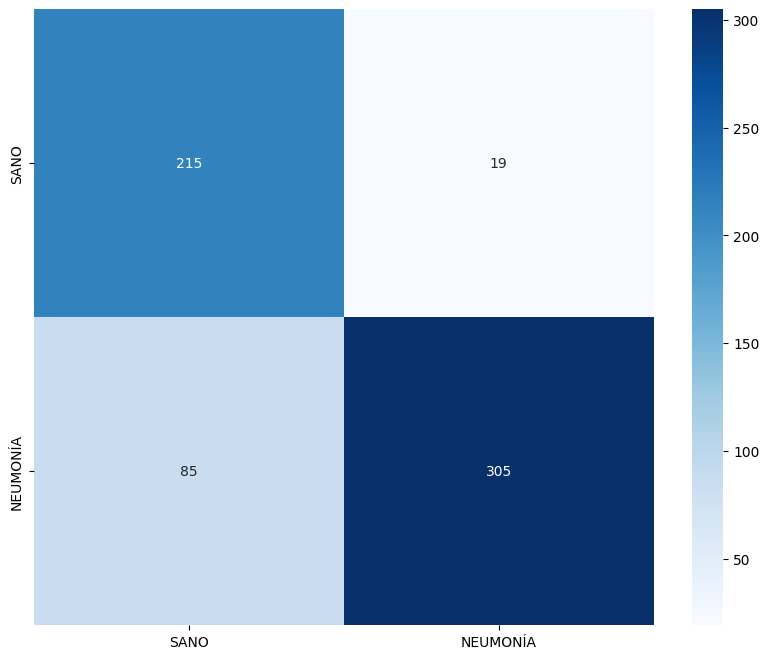

In [70]:
cm2 = confusion_matrix(y_true2, y_pred2)
print(cm2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['SANO', 'NEUMONÍA'], 
            yticklabels=['SANO', 'NEUMONÍA'])

------------------------------------------------------------

# Modelo3

con cambios en el ImageDataGenerator, cambio de arquitectura, cambio learning_rate, cambio en el early stop, se agrego reduce_lr y mas epocas

In [ ]:
train3 = ImageDataGenerator(
    rescale=1/255,

    
    rotation_range=15,            
    horizontal_flip=True,
    vertical_flip=True,          
    height_shift_range=0.1,
    zoom_range=0.2,              
    brightness_range=[0.8, 1.2], 
    shear_range=0.1,            
    fill_mode='nearest'         
)
Train_dataset3= train3.flow_from_directory("C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/train/", 
                                          target_size= (200,200),
                                          batch_size = 32,
                                          class_mode = 'binary')

Found 5216 images belonging to 2 classes.


In [ ]:
model3 = Sequential()


model3.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(200, 200, 3)))
model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model3.add(MaxPooling2D((2, 2)))


model3.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model3.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model3.add(MaxPooling2D((2, 2)))


model3.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model3.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model3.add(Conv2D(128, (3, 3), activation='relu', padding='same'))  
model3.add(MaxPooling2D((2, 2)))


model3.add(Conv2D(256, (3, 3), activation='relu', padding='same'))  
model3.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model3.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model3.add(MaxPooling2D((2, 2)))

model3.add(Flatten())
model3.add(Dense(512, activation='relu'))  
model3.add(Dropout(0.5))
model3.add(Dense(256, activation='relu'))  
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid'))

c:\Users\Usuaria\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
CNn3=model3
optimizer_= Adam(learning_rate=0.0001)

CNn3.compile(
    optimizer=optimizer_,
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

early_stop2 = EarlyStopping(
    monitor='val_loss',           
    patience=4,                   
    restore_best_weights=True,    
    verbose=1
)


reduce_lr = ReduceLROnPlateau(  
    monitor='val_loss',   
    factor=0.5,                    
    patience=2,                   
    min_lr=0.000001,               
    verbose=1
)

In [20]:
history3 = CNn3.fit(
    Train_dataset3,        
    epochs=40,                     
    validation_data=Val_dataset,
    callbacks=[early_stop2,reduce_lr],        
    verbose=1
)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.8980 - loss: 0.2546 - precision: 0.9428 - recall: 0.9185 - val_accuracy: 0.6875 - val_loss: 0.9789 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 2.5000e-05
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8933 - loss: 0.2529 - precision: 0.9397 - recall: 0.9160
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.8926 - loss: 0.2509 - precision: 0.9381 - recall: 0.9159 - val_accuracy: 0.6875 - val_loss: 0.5983 - val_precision: 0.6364 - val_recall: 0.8750 - learning_rate: 2.5000e-05
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.8986 - loss: 0.2343 - precision: 0.9431 - recall: 0.9190 - val_accuracy: 0.6875 - val_loss: 0.9540 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.2500e-05
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9133 - loss: 0.2156 - precision

In [ ]:
CNn3.save('CNn3.h5') 

In [39]:
test_loss, test_accuracy, test_precision, test_recall = CNn3.evaluate(Test_dataset, verbose=1)

print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
print(f"Precision: {test_precision:.4f} ({test_precision:.1%})")
print(f"Recall: {test_recall:.4f} ({test_recall:.1%})")


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 367ms/step - accuracy: 0.8446 - loss: 0.3857 - precision: 0.8672 - recall: 0.8872
Loss: 0.3857
Accuracy: 0.8446 (84.5%)
Precision: 0.8672 (86.7%)
Recall: 0.8872 (88.7%)


In [23]:
y_pred_prob3 = CNn3.predict(Test_dataset)
y_pred3 = (y_pred_prob3 > 0.5).astype(int).flatten()
y_true3 = Test_dataset.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 387ms/step


In [24]:
f1_3 = f1_score(y_true3, y_pred3)
print(f"\nF1-SCORE: {f1_3:.4f} ({f1_3:.1%})")


F1-SCORE: 0.8771 (87.7%)


[[181  53]
 [ 44 346]]


<Axes: >

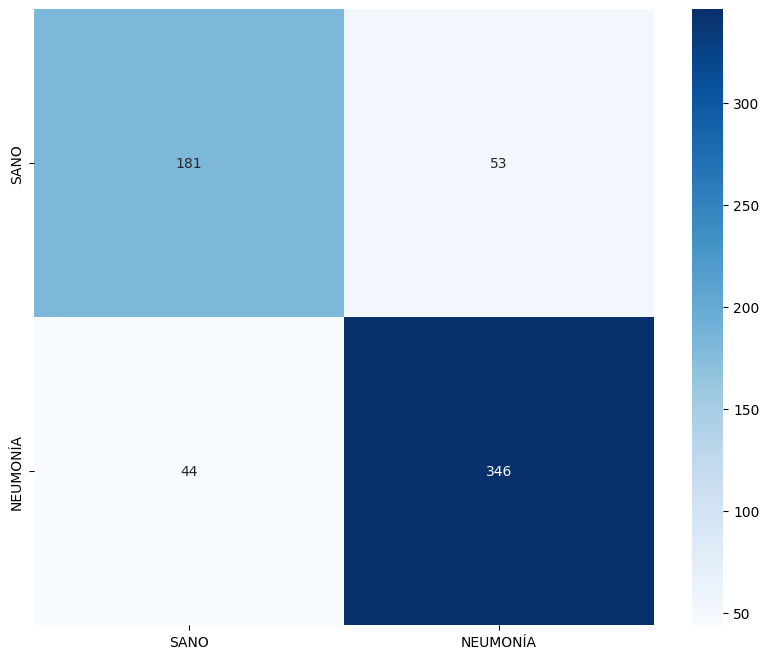

In [25]:
cm3 = confusion_matrix(y_true3, y_pred3)
print(cm3)
plt.figure(figsize=(10, 8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['SANO', 'NEUMONÍA'], 
            yticklabels=['SANO', 'NEUMONÍA'])

----------------------------------------------

# Modelo 4 

con cambios en el ImageDataGenerator, cambio de arquitectura/, cambio reduce_lr, uso de early sotp de modelo2

In [ ]:
train4 = ImageDataGenerator(
    rescale=1/255,
    
    rotation_range=20,           
    horizontal_flip=True,
    vertical_flip=True,          
    width_shift_range=0.15,      
    height_shift_range=0.15,     
    zoom_range=0.2,              
    brightness_range=[0.85, 1.15], 
    shear_range=0.15,            
    fill_mode='nearest'
)

Train_dataset4 = train4.flow_from_directory(
    "C:/Users/Usuaria/Desktop/automatizacion/lab2/chest_xray/train/", 
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary'
)

In [ ]:
model4 = Sequential()


model4.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(200, 200, 3)))
model4.add(BatchNormalization())
model4.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(MaxPooling2D((2, 2)))
model4.add(Dropout(0.25))


model4.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(MaxPooling2D((2, 2)))
model4.add(Dropout(0.3))


model4.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(MaxPooling2D((2, 2)))
model4.add(Dropout(0.4))


model4.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model4.add(BatchNormalization())
model4.add(MaxPooling2D((2, 2)))
model4.add(Dropout(0.5))


model4.add(Flatten())
model4.add(Dense(512, activation='relu'))
model4.add(Dropout(0.5))

model4.add(Dense(1, activation='sigmoid'))



In [ ]:
CNn4=model4

CNn4.compile(optimizer=optimizer_,
              loss='binary_crossentropy',
              metrics=['accuracy','precision','recall'])


reduce_lr1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,                    
    min_lr=0.000001,
    verbose=1
)

In [ ]:
history4 = CNn4.fit(
    Train_dataset4,        
    epochs=40,                     
    validation_data=Val_dataset,
    callbacks=[early_stop,reduce_lr1],        
    verbose=1
)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 541s 3s/step - accuracy: 0.8121 - loss: 0.6077 - precision: 0.8690 - recall: 0.8797 - val_accuracy: 0.5000 - val_loss: 9.6861 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.8819 - loss: 0.2797 - precision: 0.9225 - recall: 0.9182 - val_accuracy: 0.5000 - val_loss: 10.4650 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.8911 - loss: 0.2514 - precision: 0.9312 - recall: 0.9215 - val_accuracy: 0.6875 - val_loss: 2.3397 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.8946 - loss: 0.2454 - precision: 0.9344 - recall: 0.9228 - val_accuracy: 0.7500 - val_loss: 0.6355 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 540

In [ ]:
CNn4.save('CNn4.h5') 

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = CNn4.evaluate(Test_dataset, verbose=1)

print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
print(f"Precision: {test_precision:.4f} ({test_precision:.1%})")
print(f"Recall: {test_recall:.4f} ({test_recall:.1%})")

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 526ms/step - accuracy: 0.8429 - loss: 0.7883 - precision: 0.8706 - recall: 0.8795
Loss: 0.7883
Accuracy: 0.8429 (84.3%)
Precision: 0.8706 (87.1%)
Recall: 0.8795 (87.9%)


In [ ]:
y_pred_prob4 = CNn4.predict(Test_dataset)
y_pred4 = (y_pred_prob4 > 0.5).astype(int).flatten()
y_true4 = Test_dataset.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 519ms/step


In [ ]:
f1_4 = f1_score(y_true4, y_pred4)
print(f"\nF1-SCORE: {f1_4:.4f} ({f1_4:.1%})")


F1-SCORE: 0.8750 (87.5%)


[[183  51]
 [ 47 343]]


<Axes: >

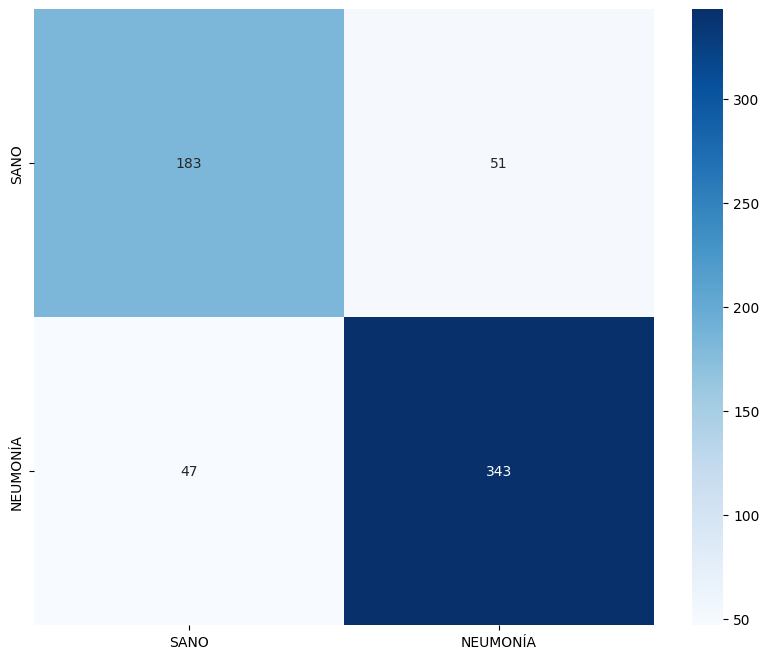

In [ ]:
cm4 = confusion_matrix(y_true4, y_pred4)
print(cm4)
plt.figure(figsize=(10, 8))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['SANO', 'NEUMONÍA'], 
            yticklabels=['SANO', 'NEUMONÍA'])

---------------------------------------------------------------------

Se elgio el modelo3 como el mejor


In [9]:
modelo_cargado3= load_model('CNn3.h5')

val_results= modelo_cargado3.evaluate(Val_dataset,verbose=0)
print(f"Val  - Loss: {val_results[0]:.4f}, Accuracy: {val_results[1]:.4f}, Precision: {val_results[2]:.4f}, Recall: {val_results[3]:.4f}")

c:\Users\Usuaria\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Val  - Loss: 0.9789, Accuracy: 0.6875, Precision: 0.6154, Recall: 1.0000


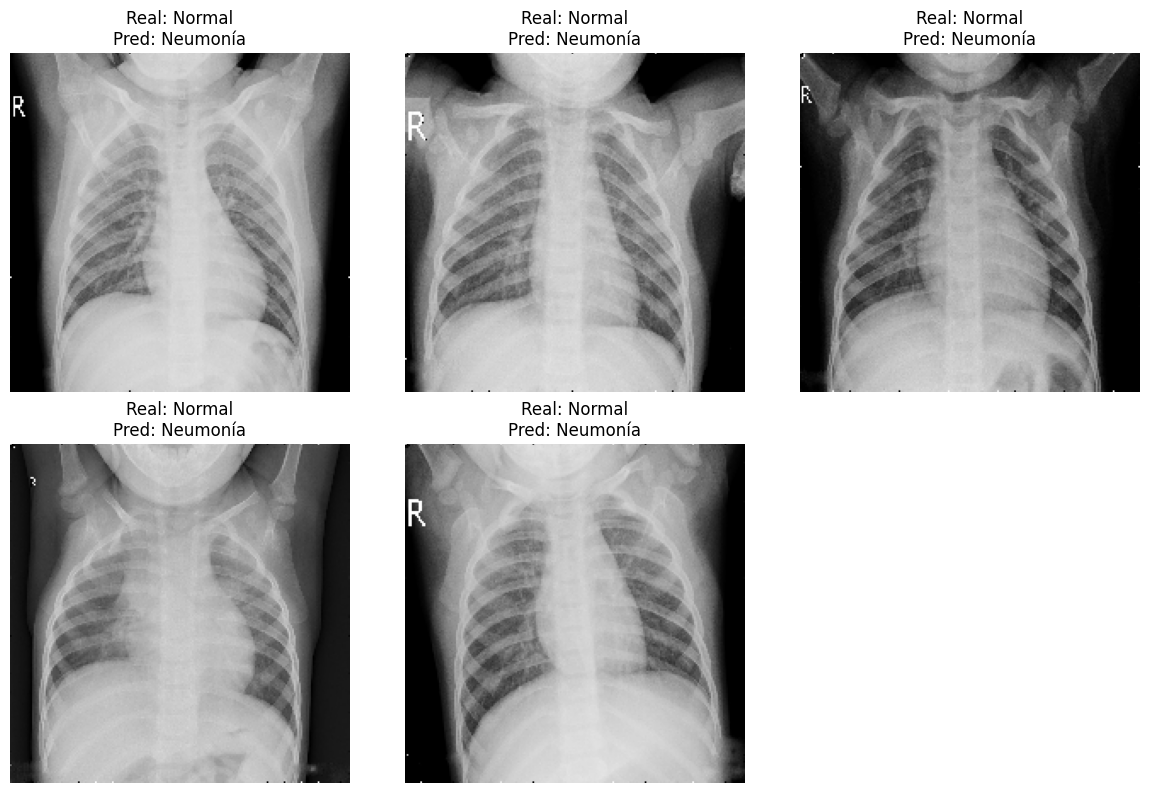

In [ ]:
import matplotlib.pyplot as plt


modelo = load_model('CNn3.h5')


for imagenes, etiquetas in Val_dataset:
   
    predicciones = modelo.predict(imagenes, verbose=0)
    predicciones_clase = (predicciones > 0.5).astype(int).flatten()
    
 
    malas = []
    for i in range(len(imagenes)):
        if predicciones_clase[i] != etiquetas[i]:
            malas.append({
                'imagen': imagenes[i],
                'real': 'Neumonía' if etiquetas[i] == 1 else 'Normal',
                'pred': 'Neumonía' if predicciones_clase[i] == 1 else 'Normal'
            })
    
   
    plt.figure(figsize=(12, 8))
    for i, mala in enumerate(malas[:6]):
        plt.subplot(2, 3, i+1)
        plt.imshow(mala['imagen'])
        plt.title(f'Real: {mala["real"]}\nPred: {mala["pred"]}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    break  

CNn4                             CNn3                             CNn2                          CNn                            
                            
Loss: 0.7883                     Loss: 0.3857                     Loss: 0.3660                     Loss: 0.5471
 
Accuracy: 0.8429 (84.3%)         Accuracy: 0.8446 (84.5%)         Accuracy: 0.8333 (83.3%)         Accuracy: 0.7772 (77.7%)

Precision: 0.8706 (87.1%)        Precision: 0.8672 (86.7%)        Precision: 0.9414 (94.1%)        Precision: 0.7485 (74.9%)

Recall: 0.8795 (87.9%)           Recall: 0.8872 (88.7%)           Recall: 0.7821 (78.2%)           Recall: 0.9692 (96.9%)


